In [12]:
# Cell 0 — CONFIG
#case
case_name = "304_met_multi_4"
experiment = "autocam1"
asset_name = f"{case_name}_{experiment}"
import json
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
sys.path.insert(0, str(project_root / "src" / "Two2D"))  # only path this notebook sets; A_Config adds the rest on import

from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
# These two are the PARENT stage folders. Each recon's own frame set now lives in a
# beat-keyed subfolder of them, handed out by build_recon_requests as job["frames_dir"].
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project_root: /workspace/project
/workspace/project True
/workspace/project/Data/304_met_multi_4/010_source
Case    : 304_met_multi_4
Video   : 04.mp4
video fps: 25.000
total_frames 609


In [3]:
print(VGGT_O_output_dir)
print(frames_for_recon)

/workspace/project/Data/07_Tropea_cafe/035_VGGT_O_output/autocam1
/workspace/project/Data/07_Tropea_cafe/020_frames_for_recon/autocam1


In [17]:
#FRAME SELECTION - one frame set per recon job
from Two2D.B_video_processing import image_sequencer

capacity  = 200      # frames one recon can hold
window    = fps/2    # search window for sharpness
min_sharp = 0.0      # raise this after inspecting selection_log.json


results = image_sequencer(
    video_path    = str(video_path),
    output_dir    = frames_for_recon,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame   = 282,
    end_frame     = 382,
)
print(f"  {len(results)} frames written to {frames_for_recon}")



Sampling: every frame (interval not set)
Video   : 04.mp4
          25 fps · 609 frames · 24.4s
Range   : frames 282-382 (100 frames)
Window  : ±0 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 100/100 [00:01<00:00, 80.72fr/s]


Selected: 100 frames  (0 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 100/100 [00:04<00:00, 22.76fr/s]

Log     : /workspace/project/Data/304_met_multi_4/020_frames_for_recon/autocam1/selection_log.json
Sharpness (at 25% res): min 1867 · mean 1996 · max 2096
  2 frames written to /workspace/project/Data/304_met_multi_4/020_frames_for_recon/autocam1


In [16]:
#VGGT OMEGA 
#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega
run_vggt_omega(image_dir=str(frames_for_recon), 
               output_dir=VGGT_O_output_dir,checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                            / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"), 
vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
image_resolution=512, conf_thres=20.0, max_points=0, show_cam=True, )

100 frames  →  /workspace/project/Data/304_met_multi_4/035_VGGT_O_output/autocam1
GPU freed -- 0.01 GiB still allocated, 0.20 GiB reserved
Saved: /workspace/project/Data/304_met_multi_4/035_VGGT_O_output/autocam1/predictions.npz
Saved: /workspace/project/Data/304_met_multi_4/035_VGGT_O_output/autocam1/scene.glb


PosixPath('/workspace/project/Data/304_met_multi_4/035_VGGT_O_output/autocam1/predictions.npz')

In [14]:
print(vggt_o_output_dir()/"predictions.npz")

/workspace/project/Data/304_met_multi_4/035_VGGT_O_output/autocam1/predictions.npz


In [17]:

from Thr3D.F_post_recon_processing import Reconstruction
recon = Reconstruction.load(frames_for_recon, vggt_o_output_dir()/"predictions.npz", FRAME_NAME_FMT)


In [18]:
conf_vggt     = recon.preds["depth_conf"].cpu().numpy()

print(conf_vggt.min(), conf_vggt.max())
print(conf_vggt.shape)
print(np.percentile(conf_vggt, [5,10, 25, 50, 75, 95]))

1.0000002 3.199602
(100, 384, 688)
[1.00004244 1.00010991 1.00133324 1.02164972 1.37111464 2.09161046]


# lingbot-map RECON

In [4]:
print(frames_for_recon)

/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/autocam1


In [157]:
from A_Config import frames_for_recon_dir
from run_models.B_lingbot_map import run_lingbot_map, load_lingbot_frame

result = run_lingbot_map(image_dir=frames_for_recon)  # same frames VGGT-O used for this case/experiment
print(result)

frame = load_lingbot_frame(result["output_dir"], result["frame_nums"][0])
print({k: v.shape for k, v in frame.items()})


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading 100 images...


Loading images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 358.40it/s]


Preprocessed images to 518x294 using canonical crop mode
flashinfer not available
Building model...
pretrained_path: 


Failed to load pretrained weights: [Errno 2] No such file or directory: ''


Loading checkpoint: /workspaces/MScPROJECT_LOCAL/Models/lingbot-map/checkpoints/lingbot-map-long.pt
  Checkpoint loaded.
Casting aggregator to torch.bfloat16 (heads kept in fp32)
Input: 100 frames, shape (100, 3, 294, 518)
Mode: streaming
GPU mem after load: alloc=3.54 GB, reserved=6.09 GB
Running streaming inference (dtype=torch.bfloat16)...


Streaming inference: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.74it/s]


Inference done in 17.3s
GPU peak during inference: 14.50 GB (reserved peak 16.46 GB)
Moving results to CPU...
{'output_dir': PosixPath('/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/036_lingbot_map_output/autocam1'), 'frame_nums': [3900, 3901, 3902, 3903, 3904, 3905, 3906, 3907, 3908, 3909, 3910, 3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3936, 3937, 3938, 3939, 3940, 3941, 3942, 3943, 3944, 3945, 3946, 3947, 3948, 3949, 3950, 3951, 3952, 3953, 3954, 3955, 3956, 3957, 3958, 3959, 3960, 3961, 3962, 3963, 3964, 3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999]}
{'depth': (294, 518, 1), 'depth_conf': (294, 518), 'extrinsic_w2c': (3, 4), 'intrinsic': (3, 3)}


In [158]:
from F_transpose_to_recon_objects import lingbot_map_to_reconstruction
lingconstruction = lingbot_map_to_reconstruction(frames_for_recon, result["output_dir"])

# MEGASAM RECON

In [24]:
# Cell — MegaSaM reconstruction (mono-depth -> camera tracking -> CVD optimisation)
# requires the `mega_sam` conda env (Linux devcontainer only, see
# Models/mega-sam/LINUX_SETUP_CHANGELOG.md) — not available if running this
# notebook natively on Windows.

'''this will replace CUT3R probably'''
import importlib, sys, traceback
sys.path.insert(0, str(project_root / "src"))

from run_models.E_megasam_recon import run_megasam

mega_sam_dir = project_root / "Models" / "mega-sam"

try:
    megasam_npz = run_megasam(
        frames_dir   = frames_for_recon,
        mega_sam_dir = mega_sam_dir,
        scene_name   = case_name,
    )
except Exception:
    traceback.print_exc()


$ conda run --no-capture-output -n mega_sam python Depth-Anything/run_videos.py --encoder vitl --load-from Depth-Anything/checkpoints/depth_anything_vitl14.pth --img-path /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/autocam1 --outdir Depth-Anything/video_visualization/07_Tropea_cafe


Using cache found in /cs/student/msc/cgvi/2025/dbarker/.cache/torch/hub/facebookresearch_dinov2_main


Total parameters: 335.32M


100%|██████████| 100/100 [00:19<00:00,  5.14it/s]


  Depth-Anything done in 25s
$ conda run --no-capture-output -n mega_sam python UniDepth/scripts/demo_mega-sam.py --scene-name 07_Tropea_cafe --img-path /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/autocam1 --outdir UniDepth/outputs
Torch version: 2.0.1


...

  UniDepth done in 43s
$ conda run --no-capture-output -n mega_sam python camera_tracking_scripts/test_demo.py --datapath=/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/autocam1 --weights=/workspaces/MScPROJECT_LOCAL/Models/mega-sam/checkpoints/megasam_final.pth --scene_name 07_Tropea_cafe --mono_depth_path /workspaces/MScPROJECT_LOCAL/Models/mega-sam/Depth-Anything/video_visualization --metric_depth_path /workspaces/MScPROJECT_LOCAL/Models/mega-sam/UniDepth/outputs --disable_vis
Running evaluation on /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/autocam1
************** UNIDEPTH FOV  57.22323065445491


0it [00:00, ?it/s]/cs/student/project_msc/2025/cgvi/dbarker/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995026/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100it [00:01, 58.24it/s]


/workspaces/MScPROJECT_LOCAL/Models/mega-sam/checkpoints/megasam_final.pth
################################
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
median_hessian, median_calib  tensor(78.3786, device='cuda:0') tensor([439.2327], device='cuda:0')
_opt_intr  True  use_mono  False  alpha  0.0
################## KEYFRAME BUNDLE ADJUSTMENT ################################  use_mono  False
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
Global BA Iteration #11
Global BA Iteration #12
Global BA Iteration #13
Global BA Iteration #14
Global BA Iteration #15
Global BA Iteration #16
Global BA Iteration #17
Global BA Iteration #1

100it [00:01, 61.59it/s]
  0%|          | 0/99 [00:00<?, ?it/s]/cs/student/project_msc/2025/cgvi/dbarker/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995026/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 85/85 [00:03<00:00, 22.77it/s]


  RAFT flow done in 26s
$ conda run --no-capture-output -n mega_sam python cvd_opt/cvd_opt.py --scene_name 07_Tropea_cafe --w_grad 2.0 --w_normal 5.0
CVD optimisation: 07_Tropea_cafe
step  0 0.25160661339759827
step  20 0.1611550897359848
step  40 0.10400939732789993
step  60 0.0646669790148735
step  80 0.03487640619277954
step  0 0.01073532272130251
step  20 0.10082987695932388
step  40 0.0019700373522937298
step  60 -0.03264155611395836
step  80 -0.04988870397210121
step  100 -0.062128521502017975
step  120 -0.07269228249788284
step  140 -0.08191625028848648
step  160 -0.09083721786737442
step  180 -0.09902969002723694
step  200 -0.10655396431684494
step  220 -0.11380106210708618
step  240 -0.1203908622264862
step  260 -0.12687528133392334
step  280 -0.13304403424263
step  300 -0.13870355486869812
step  320 -0.14430710673332214
step  340 -0.1494005024433136
step  360 -0.15449556708335876
step  380 -0.15920481085777283
  CVD optimisation done in 99s
Output: /workspaces/MScPROJECT_LOCA

In [32]:
from F_transpose_to_recon_objects import megasam_to_reconstruction
from A_Config import mega_SAM_output_dir
npz_path = mega_SAM_output_dir() / f"{case_name}_sgd_cvd_hr.npz"
megacon = megasam_to_reconstruction(frames_for_recon, npz_path)
conf_MegaSaM   = megacon.preds["depth_conf"].cpu().numpy()
print(conf_MegaSaM.min(), conf_MegaSaM.max())
print(conf_MegaSaM.shape)
print(np.percentile(conf_MegaSaM, [5,10, 25, 50, 75, 95]))


0.000100016594 2.6660156
(100, 328, 584)
[1.34375    2.015625   2.38085938 2.51757812 2.57226562 2.60546875]


# geo skippable

A,B 29 29


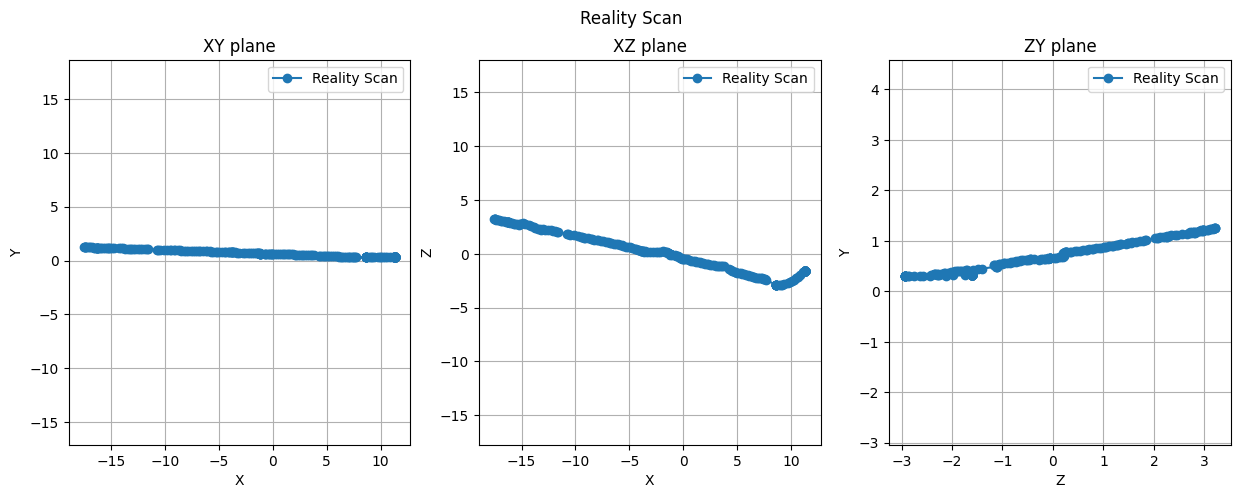

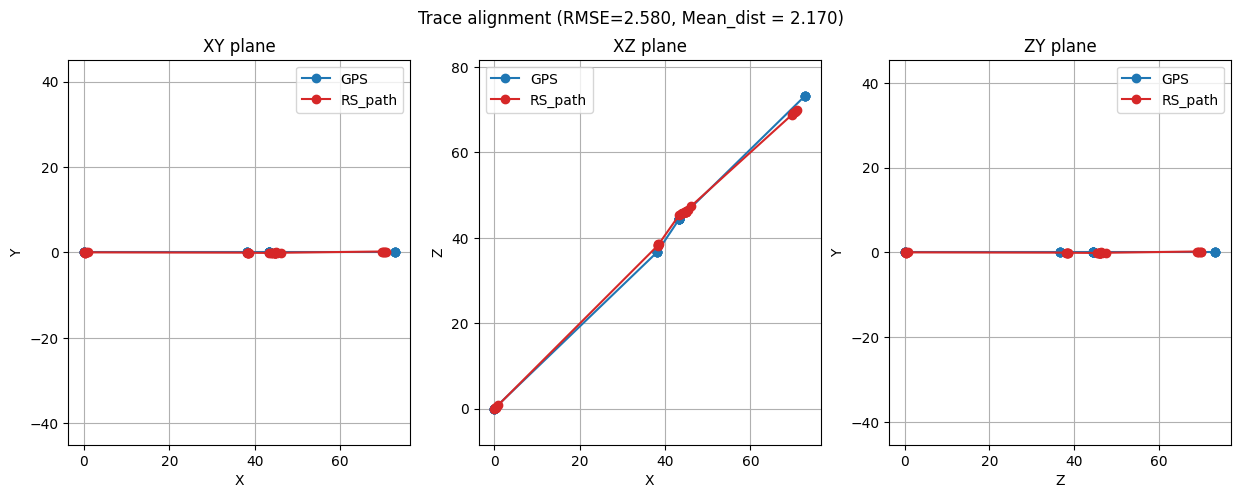

In [10]:
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 


#get lat lon positions
#get transforms to convert other things too
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, csv_path_pose)



In [ ]:
#Convert into model space and export into plys
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
ext = recon.preds["extrinsic"][0].clone()

if MULTI_PART_RECON == False:
        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
       
        _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , 
                                             conf_threshold=1.1, 
                                             R=ext[:,0:3], 
                                             t=ext[:,3], 
                                             s=1)
        
        print(predictions_path)
else:
        print("Cell disabled")


In [ ]:
# Cell — PLY visualisation
   
import importlib, sys
sys.path.insert(0, str(project_root / "src"))


from Thr3D.F_cut3r_vis import visualise_cut3r
visualisation_dir = case_dir   /  VGGT_O_output_dir
#visualisation_dir = case_dir   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)


Found 100 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 20 persistent messages

In [12]:
print((recon.preds["images"].shape))

torch.Size([100, 3, 384, 688])


A,B 4 4
Subject VGGT-O → real-world: 4 pairs, RMSE = 0.0077 m
[3900, 3901, 3902, 3903, 3904, 3905, 3906, 3907, 3908, 3909, 3910, 3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3936, 3937, 3938, 3939, 3940, 3941, 3942, 3943, 3944, 3945, 3946, 3947, 3948, 3949, 3950, 3951, 3952, 3953, 3954, 3955, 3956, 3957, 3958, 3959, 3960, 3961, 3962, 3963, 3964, 3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999]
/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/autocam1/predictions.npz


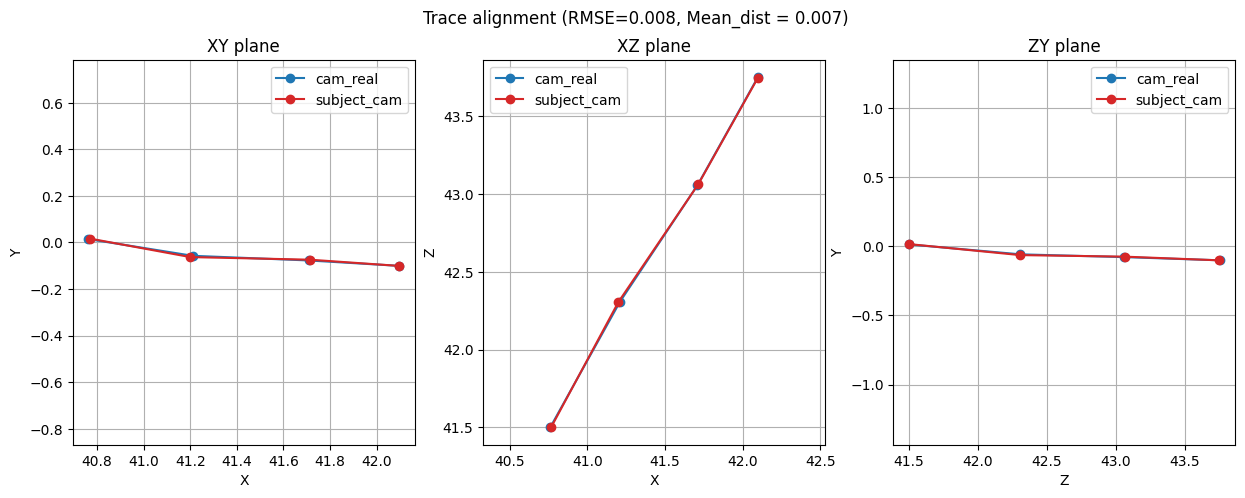

In [19]:
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in


from Q_subject_analysis import subject_to_metric_and_gps_space
from G_transforms_alignments import  recon_to_recon_transform
R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
    recon,
    masks_dir        = str(yolo_masks_dir),
    lat_0=lat_0, lon_0=lon_0,
    R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
    )    

#MAKE PLYS of VGGT__O
#turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
#n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
_ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)

print(predictions_path)


# Auto camera (prototype, test 1)
Automated rotation (weighted quaternion average of cameras that saw the subject) + translation (fit the subject's 3D bounding box in frame). See src/changelog.txt for details.

In [65]:
from Two2D.B_video_processing import available_frames
#dual setup
# every knob visible and tweakable right here -- raw VGGT-O model units, no metric/GPS needed
margin                  = 0   #fraction of to the full-mask-point box, on every side
extra_distance_margin   = 0.0
   # extra pull-back so off-center corners don't clip
conf_percentile         = 30  # drop masked pixels below this depth-confidence percentile
                               # (guards against a misprojected frame blowing the box out --

sr = 3 #splat radius                          
masks_dir = case_dir() / "015_SAM3_masks_old"/"person_14"/"person-1"
#masks_dir = None
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
print(extra_indices)


[282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381]


# VGGT OMEGA CAM

In [66]:
from Q_subject_analysis import find_mask_centroids_in_model_space, auto_camera_position, look_at_rotation, subject_oriented_box
from P_projection_mapping import solve_auto_camera_extrinsic, projection_mapping_sequence

ct_vggt  = np.percentile(conf_vggt, conf_percentile)  

subject_cenroids_model, frame_keys, _ ,_ ,weights, mask_points = find_mask_centroids_in_model_space(
    recon, masks_dir, autocam=True,
    conf_thresh=ct_vggt,
)

# Position from the weighted-average of where the real cameras stood (a robust
# signal), 
down_refs = recon.preds["extrinsic"].cpu().numpy()[:, 1, :3]   # each frame's own down axis, model space
up_model = -(down_refs[weights > 0] * weights[weights > 0, None]).sum(axis=0)
up_model /= np.linalg.norm(up_model)

C_avg = auto_camera_position(recon.preds["extrinsic"].cpu().numpy(), weights)
# One oriented box, used for BOTH the framing solve and the debug draw. Fitting the
# raw points instead let the box's corners (extreme in all 3 axes at once) stick out
# past every real point and shoot off-screen.
obb_corners = subject_oriented_box(mask_points, margin = margin,percentile=95)
box_center = obb_corners.mean(axis=0)
R_auto_c2w = look_at_rotation(C_avg, box_center, up_model)

new_view = solve_auto_camera_extrinsic(
    obb_corners, box_center, R_auto_c2w,
    recon.preds["intrinsic"][0].cpu().numpy(),
    recon.preds["depth"].shape[1:],
    extra_distance_margin=extra_distance_margin,
    dtype=recon.preds["extrinsic"].dtype,
)

print("R_auto orthonormal check:", np.allclose(R_auto_c2w @ R_auto_c2w.T, np.eye(3), atol=1e-4), "det:", np.linalg.det(R_auto_c2w))
print("C_avg (model units):", C_avg, "box_center:", box_center)
print("weights: min/max/mean/#nonzero:", weights.min(), weights.max(), weights.mean(), (weights > 0).sum())
#---------------------------------------------------------------------------------------------

#new_view = recon.preds["extrinsic"][-1]
subject_positions = projection_mapping_sequence(
    recon=recon,
    extra_indices=extra_indices,  # one output frame per source frame, default naming
    #extra_indices= [282],  # one output frame per source frame, default naming
    new_view=new_view,
    confidence_threshold=ct_vggt,
    #masks_dir = masks_dir,
    use_lowres_images=False,
    splat_radius = sr,
    frame_rate = fps
)
#---------------------------------------------------------------------------------------------------------------------------------------



/workspace/project/src/Q_subject_analysis.py:48: RuntimeWarning: invalid value encountered in divide
  (frame -> distance) that's computed internally on the way to the closest-approach
/workspace/project/src/Q_subject_analysis.py:52: RuntimeWarning: invalid value encountered in divide
  A_frames = np.array(sorted(A_real_dict.keys()))
/workspace/project/src/Q_subject_analysis.py:55: RuntimeWarning: invalid value encountered in divide
  B_frames = np.array(sorted(B_real_dict.keys()))


511.93567706242453


/workspace/project/src/Q_subject_analysis.py:61: RuntimeWarning: invalid value encountered in divide
  matched_B_frames = B_frames[nearest_idx]


R_auto orthonormal check: True det: 1.0000000000000002
C_avg (model units): [0.08104643 0.00455983 0.19643433] box_center: [0.35838838 0.11492103 1.2136535 ]
weights: min/max/mean/#nonzero: 0.0 0.38073085349073305 0.22414841601647806 91


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

# Lingbot CAM



In [203]:
from Q_subject_analysis import find_mask_centroids_in_model_space, auto_camera_position, look_at_rotation, subject_oriented_box
from P_projection_mapping import solve_auto_camera_extrinsic, projection_mapping_sequence

# Everything here is _ling-suffixed. The VGGT-O cell above uses the same bare names, so
# whichever cell ran last would otherwise own them for every cell below this one.

subject_cenroids_model_ling, frame_keys_ling, weights_ling, mask_points_ling = find_mask_centroids_in_model_space(
    lingconstruction, str(yolo_masks_dir), autocam=True,
    conf_thresh=ct,
)

# Position from the weighted-average of where the real cameras stood (a robust
# signal),
down_refs_ling = lingconstruction.preds["extrinsic"].cpu().numpy()[:, 1, :3]   # each frame's own down axis, model space
up_model_ling = -(down_refs_ling[weights_ling > 0] * weights_ling[weights_ling > 0, None]).sum(axis=0)
up_model_ling /= np.linalg.norm(up_model_ling)

C_avg_ling = auto_camera_position(lingconstruction.preds["extrinsic"].cpu().numpy(), weights_ling)
# One oriented box, used for BOTH the framing solve and the debug draw.
obb_corners_ling = subject_oriented_box(mask_points_ling, margin=margin, percentile=95)
box_center_ling = obb_corners_ling.mean(axis=0)
R_auto_c2w_ling = look_at_rotation(C_avg_ling, box_center_ling, up_model_ling)

new_view_ling = solve_auto_camera_extrinsic(
    obb_corners_ling, box_center_ling, R_auto_c2w_ling,
    lingconstruction.preds["intrinsic"][0].cpu().numpy(),
    lingconstruction.preds["depth"].shape[1:],
    extra_distance_margin=extra_distance_margin,
    dtype=lingconstruction.preds["extrinsic"].dtype,
)
new_view_ling = lingconstruction.preds["extrinsic"][-1]
print("R_auto orthonormal check:", np.allclose(R_auto_c2w_ling @ R_auto_c2w_ling.T, np.eye(3), atol=1e-4), "det:", np.linalg.det(R_auto_c2w_ling))
print("C_avg (model units):", C_avg_ling, "box_center:", box_center_ling)
print("weights: min/max/mean/#nonzero:", weights_ling.min(), weights_ling.max(), weights_ling.mean(), (weights_ling > 0).sum())
#---------------------------------------------------------------------------------------------
#render
ling_render_name = f"{asset_name}_ling_proj_aug.png"
subject_positions_ling = projection_mapping_sequence(
    recon=lingconstruction,
    extra_indices=extra_indices,  # nested = one fused output frame
    new_view=new_view_ling,
    confidence_threshold=ct,
    masks_dir = masks_dir,
    use_lowres_images=False,
    splat_radius = sr,
)



[3900, 3901, 3902, 3903, 3904, 3905, 3906, 3907, 3908, 3909, 3910, 3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3936, 3937, 3938, 3939, 3940, 3941, 3942, 3943, 3944, 3945, 3946, 3947, 3948, 3949, 3950, 3951, 3952, 3953, 3954, 3955, 3956, 3957, 3958, 3959, 3960, 3961, 3962, 3963, 3964, 3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999]
R_auto orthonormal check: True det: 1.0000000000000002
C_avg (model units): [-0.01799466 -0.00547807  0.13664248] box_center: [-0.02138276  0.07306314  0.79740511]
weights: min/max/mean/#nonzero: 0.0 0.6776473309176834 0.39163261043435504 73


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

# MegaSAM

In [34]:
from Q_subject_analysis import find_mask_centroids_in_model_space, auto_camera_position, look_at_rotation, subject_oriented_box
from P_projection_mapping import solve_auto_camera_extrinsic, projection_mapping_sequence

# Everything here is _MegaSAM-suffixed. The VGGT-O cell above uses the same bare names, so
# whichever cell ran last would otherwise own them for every cell below this one.
ct_mega = np.percentile(conf_MegaSaM,conf_percentile )
subject_cenroids_model_MegaSAM, frame_keys_MegaSAM, weights_MegaSAM, mask_points_MegaSAM = find_mask_centroids_in_model_space(
    megacon, str(yolo_masks_dir), autocam=True,
    conf_thresh=ct_mega,
)

# Position from the weighted-average of where the real cameras stood (a robust
# signal),
down_refs_MegaSAM = megacon.preds["extrinsic"].cpu().numpy()[:, 1, :3]   # each frame's own down axis, model space
up_model_MegaSAM = -(down_refs_MegaSAM[weights_MegaSAM > 0] * weights_MegaSAM[weights_MegaSAM > 0, None]).sum(axis=0)
up_model_MegaSAM /= np.linalg.norm(up_model_MegaSAM)

C_avg_MegaSAM = auto_camera_position(megacon.preds["extrinsic"].cpu().numpy(), weights_MegaSAM)
# One oriented box, used for BOTH the framing solve and the debug draw.
obb_corners_MegaSAM = subject_oriented_box(mask_points_MegaSAM, margin=margin, percentile=95)
box_center_MegaSAM = obb_corners_MegaSAM.mean(axis=0)
R_auto_c2w_MegaSAM = look_at_rotation(C_avg_MegaSAM, box_center_MegaSAM, up_model_MegaSAM)

new_view_MegaSAM = solve_auto_camera_extrinsic(
    obb_corners_MegaSAM, box_center_MegaSAM, R_auto_c2w_MegaSAM,
    megacon.preds["intrinsic"][0].cpu().numpy(),
    megacon.preds["depth"].shape[1:],
    extra_distance_margin=extra_distance_margin,
    dtype=megacon.preds["extrinsic"].dtype,
)
new_view_MegaSAM = megacon.preds["extrinsic"][-1]
print("R_auto orthonormal check:", np.allclose(R_auto_c2w_MegaSAM @ R_auto_c2w_MegaSAM.T, np.eye(3), atol=1e-4), "det:", np.linalg.det(R_auto_c2w_MegaSAM))
print("C_avg (model units):", C_avg_MegaSAM, "box_center:", box_center_MegaSAM)
print("weights: min/max/mean/#nonzero:", weights_MegaSAM.min(), weights_MegaSAM.max(), weights_MegaSAM.mean(), (weights_MegaSAM > 0).sum())
#---------------------------------------------------------------------------------------------
#render
MegaSAM_render_name = f"{asset_name}_MegaSAM_proj_aug.png"
subject_positions_MegaSAM = projection_mapping_sequence(
    recon=megacon,
    extra_indices=extra_indices,  # nested = one fused output frame
    new_view=new_view_MegaSAM,
    confidence_threshold=ct_mega,
    masks_dir = masks_dir,
    use_lowres_images=False,
    splat_radius = sr,
)


[3900, 3901, 3902, 3903, 3904, 3905, 3906, 3907, 3908, 3909, 3910, 3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3936, 3937, 3938, 3939, 3940, 3941, 3942, 3943, 3944, 3945, 3946, 3947, 3948, 3949, 3950, 3951, 3952, 3953, 3954, 3955, 3956, 3957, 3958, 3959, 3960, 3961, 3962, 3963, 3964, 3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999]
R_auto orthonormal check: True det: 1.0000000000000004
C_avg (model units): [-0.02386611 -0.00422931  0.25606273] box_center: [-0.03817337  0.08199384  1.41547405]
weights: min/max/mean/#nonzero: 0.0 0.6787030878523718 0.3915788827218776 73


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

VGGT-O     98 diffs
LingBot_Map   98 diffs


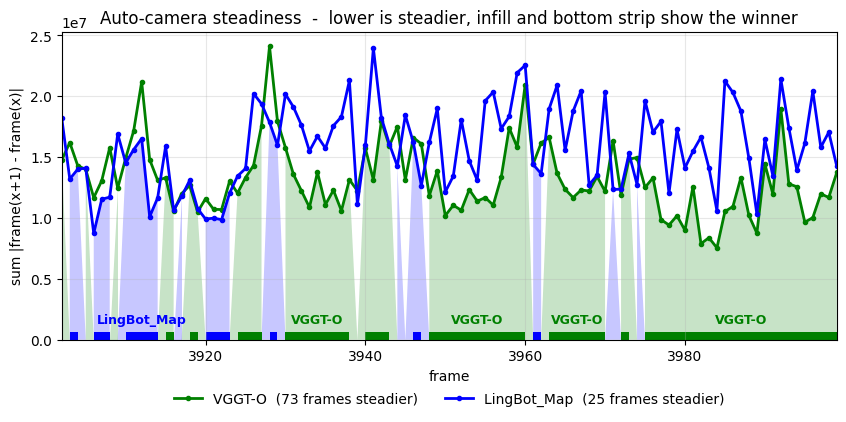

In [207]:
from pathlib import Path
import re
import numpy as np
import cv2
from matplotlib import pyplot as plt
from A_Config import assets_dir

tracks = {
    "VGGT-O":  (assets_dir() / "projection_frames" / "07_Tropea_cafe_CAMEND_projection_VGGT_O",   "green"),
    "LingBot_Map": (assets_dir() / "projection_frames" / "07_Tropea_cafe_CAMEND_projection_Ling", "blue"),
}

NORMALISE = False   # True -> divide each track by its own median, so the two are
                    # comparable despite sitting at different camera distances

def frame_num(p):
    m = re.findall(r"\d+", p.stem)
    return int(m[-1]) if m else -1

def steadiness(folder):
    paths = sorted((p for p in folder.iterdir()
                    if p.suffix.lower() in {".png", ".jpg", ".jpeg"}), key=frame_num)
    out, prev = {}, None
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = img.astype(np.float32)
        if prev is not None and img.shape == prev.shape:
            out[frame_num(p)] = float(np.abs(img - prev).sum())
        prev = img
    return out

series = {}
for label, (folder, colour) in tracks.items():
    s = steadiness(folder)
    if NORMALISE and s:
        med = np.median(list(s.values()))
        s = {k: v / med for k, v in s.items()}
    series[label] = s
    print(f"{label:8s} {len(s):4d} diffs" if s else f"{label:8s} NO FRAMES in {folder}")

(la, ca), (lb, cb) = [(l, c) for l, (_, c) in tracks.items()]
x = np.array(sorted(set(series[la]) & set(series[lb])))
a = np.array([series[la][k] for k in x])
b = np.array([series[lb][k] for k in x])
lower  = np.minimum(a, b)
a_wins = a < b                      # lower diff = steadier = winner

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x, 0, lower, where=a_wins,  interpolate=True, color=ca, alpha=0.22, linewidth=0)
ax.fill_between(x, 0, lower, where=~a_wins, interpolate=True, color=cb, alpha=0.22, linewidth=0)
ax.plot(x, a, "-o", color=ca, linewidth=2, markersize=3, label=f"{la}  ({a_wins.sum()} frames steadier)")
ax.plot(x, b, "-o", color=cb, linewidth=2, markersize=3, label=f"{lb}  ({(~a_wins).sum()} frames steadier)")

# ---- winner strip + labels along the bottom -------------------------------
ymax = float(max(a.max(), b.max()))
strip_top = 0.028 * ymax                      # height of the solid winner strip
label_y   = strip_top * 1.6                   # text sits just above the strip
min_span  = 0.035 * (x[-1] - x[0])            # don't label slivers -- too cluttered

runs, i, n = [], 0, len(a_wins)
while i < n:                                   # contiguous stretches of one winner
    j = i
    while j + 1 < n and a_wins[j + 1] == a_wins[i]:
        j += 1
    runs.append((i, j, bool(a_wins[i])))
    i = j + 1

for i, j, a_won in runs:
    lo, hi = x[i], x[j]
    colour, name = (ca, la) if a_won else (cb, lb)
    ax.fill_between([lo, hi], 0, strip_top, color=colour, linewidth=0)   # solid, full strength
    if hi - lo >= min_span:
        ax.text((lo + hi) / 2, label_y, name, ha="center", va="bottom",
                color=colour, fontsize=9, fontweight="bold", clip_on=True)

ax.set_ylim(bottom=0)
ax.margins(x=0)
ax.set_xlabel("frame")
ax.set_ylabel("sum |frame(x+1) - frame(x)|" + ("  (normalised)" if NORMALISE else ""))
ax.set_title("Auto-camera steadiness  -  lower is steadier, infill and bottom strip show the winner")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, frameon=False)
ax.grid(alpha=0.3)
plt.show()


In [ ]:

from A_Config import assets_dir
# DEBUG: render the auto-camera's box, wireframed on top of the actual render.
# Edges are clipped at the camera's near plane instead of being dropped whenever
# one endpoint is behind the camera -- so the box stays visible even when the
# camera ends up close to or inside it.
from P_projection_mapping import get_full_res_camera
import cv2

canvas_hw = (1080, 1920)   # must match composite_overlay's synthetic-view default canvas size
intrinsic_full, _, _ = get_full_res_camera(recon.preds, 0, canvas_hw)
fx, fy, cx, cy = (intrinsic_full[0,0].item(), intrinsic_full[1,1].item(),
                   intrinsic_full[0,2].item(), intrinsic_full[1,2].item())

R = new_view[:, :3].cpu().numpy()
t = new_view[:, 3].cpu().numpy()

# same 8-corner order as P_projection_mapping.solve_auto_camera_extrinsic
corners = obb_corners   # same oriented box the framing solve used
corners_cam = corners @ R.T + t   # (8,3) camera-space coords

def project(p):
    return p[0]*fx/p[2] + cx, p[1]*fy/p[2] + cy

eps = 1e-3   # near-clip plane distance
edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]

img_path = assets_dir() / "projection_frames" / f"{asset_name}_proj _VGGTO_{frame_keys[0]}-{frame_keys[-1]}_n{len(frame_keys)}_aug.png"   # actual output filename of the fused all-frames composite (extra_indices=[frame_keys])
img = cv2.imread(str(img_path))

for a, b in edges:
    pa, pb = corners_cam[a].copy(), corners_cam[b].copy()
    za, zb = pa[2], pb[2]
    if za <= eps and zb <= eps:
        continue   # whole edge behind the camera -- nothing to draw
    if za <= eps:
        pa = pa + (eps - za) / (zb - za) * (pb - pa)   # clip a to the near plane
    elif zb <= eps:
        pb = pb + (eps - zb) / (za - zb) * (pa - pb)   # clip b to the near plane
    ua, va = project(pa)
    ub, vb = project(pb)
    cv2.line(img, (int(ua), int(va)), (int(ub), int(vb)), (0, 0, 255), 3)

for i in range(8):
    if corners_cam[i, 2] > eps:
        u, v = project(corners_cam[i])
        if 0 <= u < canvas_hw[1] and 0 <= v < canvas_hw[0]:
            cv2.circle(img, (int(u), int(v)), 8, (0, 255, 0), -1)

debug_path = assets_dir() / "projection_frames" / f"{asset_name}_autocam_box_debug.png"
cv2.imwrite(str(debug_path), img)

from matplotlib import pyplot as plt
plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"box size (model units): {box_max-box_min}")
plt.axis("off")
plt.show()

print("box_min/max (model units):", box_min, box_max)
print("box size (model units):", box_max - box_min)
print("corners behind near plane:", (corners_cam[:,2] <= eps).sum(), "/8")

[3900, 3901, 3902, 3903, 3904, 3905, 3906, 3907, 3908, 3909, 3910, 3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3936, 3937, 3938, 3939, 3940, 3941, 3942, 3943, 3944, 3945, 3946, 3947, 3948, 3949, 3950, 3951, 3952, 3953, 3954, 3955, 3956, 3957, 3958, 3959, 3960, 3961, 3962, 3963, 3964, 3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999]


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

In [26]:
print(sub_pos_real_dict)
print(recon.preds["extrinsic"])

{3900: array([nan, nan, nan]), 3901: array([nan, nan, nan]), 3902: array([nan, nan, nan]), 3903: array([nan, nan, nan]), 3904: array([nan, nan, nan]), 3905: array([nan, nan, nan]), 3906: array([nan, nan, nan]), 3907: array([nan, nan, nan]), 3908: array([nan, nan, nan]), 3909: array([nan, nan, nan]), 3910: array([nan, nan, nan]), 3911: array([47.22092607,  1.03843954, 50.18038901]), 3912: array([47.21606717,  1.03777731, 50.14204423]), 3913: array([nan, nan, nan]), 3914: array([47.19157028,  1.01018414, 50.09704633]), 3915: array([47.27069697,  1.03374111, 50.21019348]), 3916: array([47.270212  ,  1.03776942, 50.19558323]), 3917: array([nan, nan, nan]), 3918: array([47.18072195,  1.0241294 , 50.0586852 ]), 3919: array([47.16819819,  1.02436504, 50.04084485]), 3920: array([47.13904627,  1.01756112, 49.98896371]), 3921: array([47.14334111,  1.02275501, 49.99578617]), 3922: array([nan, nan, nan]), 3923: array([nan, nan, nan]), 3924: array([47.14798836,  1.01240555, 49.96675434]), 3925: arr

subject moved 1.3422533717256941 m
subject moved in a 197.0222201723672 direction


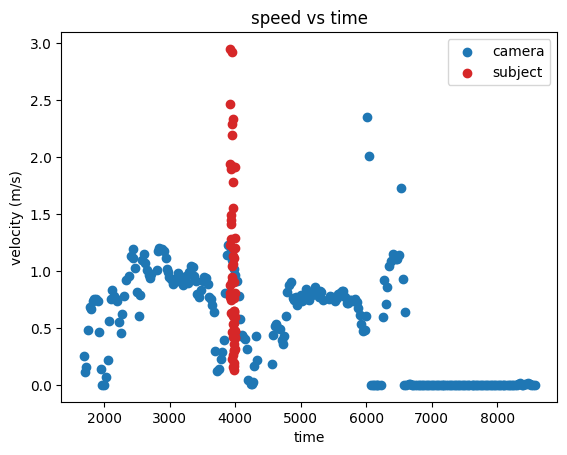

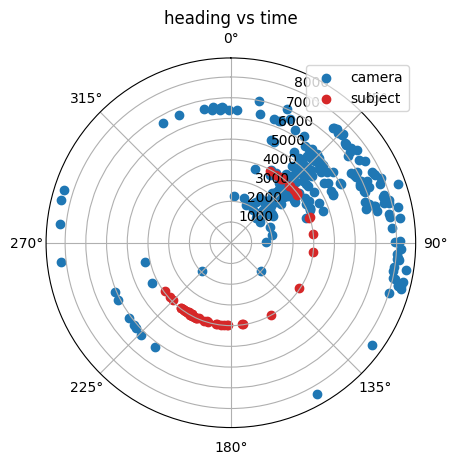

In [20]:
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(sub_pos_real_dict,cam_poses_realworld_dict,lat_0, lon_0 )



Text(0.5, 1.0, 'Subject position by shard (color = time)')

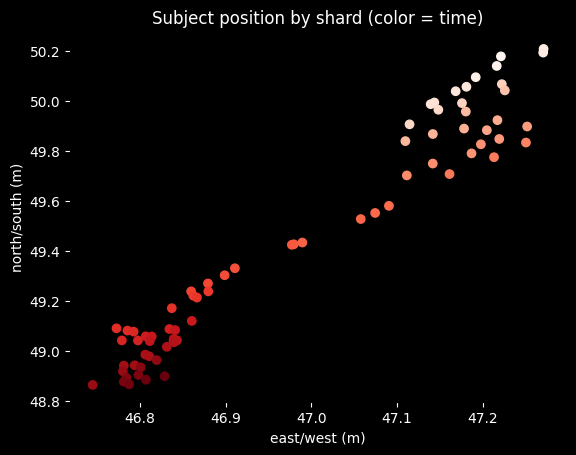

In [21]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
pts = np.array([sub_pos_real_dict[k] for k in sorted(sub_pos_real_dict)])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")


In [ ]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.

import R_map_animator

R_map_animator.main(
traces=[
    {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
    {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
],
api_key     = api_key,
gif = True,
mp4 = None


)


NameError: name 'flags' is not defined

In [56]:
#MANUAL PROOF-OF-CONCEPT, superseded by the auto-camera cells above (see src/changelog.txt)
#CAMERA TRANSFORMS - single recon at the moment
#1m up
ext = recon.preds["extrinsic"][9].clone()
ext[1, 3] += 1/16   # lift camera 1m (1/16 scale)

#10m up BEV
extBEV = recon.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=extBEV.dtype, device=extBEV.device)

extBEV = Rx @ extBEV        # pitch 90° down, camera stays where cam 9 was
extBEV[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext[1, 3] += 5/16      # forward 5m along cam 9's original heading

In [17]:
print(len(recon.preds["extrinsic"]))
print(frames_for_recon)

50
/workspaces/MScPROJECT_LOCAL/Data/01_walk/020_frames_for_recon/sparse_50_02


In [43]:
min(recon.frame_to_row.values()), len(recon.frame_to_row)


(0, 50)

In [36]:
print(frames_for_recon)
print(predictions_path)
list(recon.frames_dir.glob("*"))[:5], len(list(recon.frames_dir.glob("*")))


/workspaces/MScPROJECT_LOCAL/Data/01_walk/020_frames_for_recon/01_walk_sparse_50_02_full
/workspaces/MScPROJECT_LOCAL/Data/01_walk/035_VGGT_O_output/01_walk_sparse_50_02_full/predictions.npz


([], 0)

In [40]:


#2D projection mapping of subject to a selected view
from F_post_recon_processing import Reconstruction
from P_projection_mapping import projection_mapping_sequence
from B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
print(extra_indices)


recon = recon
#PARAMS
splat_radius = 3
lo_or_up = "up"
if lo_or_up == "up":
    use_lowres_images = False
if lo_or_up == "lo":
    use_lowres_images = True
cam = 4
ext = recon.preds["extrinsic"][cam].clone()
source = 1


point_cloud_xforms = None
subject_positions = projection_mapping_sequence(
    
    recon         = recon,
    #main_idx      = 0,
    #extra_indices = [extra_indices],
    #extra_indices = range (3854,4397),
    extra_indices = [source],
    #other syntax  [400,4027, 4052, 4065],
    #extra_indices = [extra_indices], - for composite (double [[]])
    #masks_dir     = str(yolo_masks_dir),
    new_view = ext,
    confidence_threshold = 0,
    use_lowres_images=use_lowres_images,
    splat_radius = splat_radius,
    name = f"PM_{source}_to_{cam}_{lo_or_up}_{splat_radius}.png"
    
    )


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

In [ ]:
#2D projection mapping of subject to a selected view - NO UPRES
from F_post_recon_processing import Reconstruction
from P_projection_mapping import projection_mapping_sequence
from B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
print(extra_indices)


recon = recon
point_cloud_xforms = None
subject_positions = projection_mapping_sequence(
    
    recon         = recon,
    #main_idx      = 0,
    #extra_indices = [extra_indices],
    #extra_indices = range (3854,4397),
    extra_indices = [1],
    #other syntax  [400,4027, 4052, 4065],
    #extra_indices = [extra_indices], - for composite (double [[]])
    #masks_dir     = str(yolo_masks_dir),
    new_view = ext ,
    confidence_threshold = 2
    
    )


In [ ]:
#render projection of 3D points clouds
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:

#cutr point cloud render
if flags["CUT3R_RECON"] ==True:  
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   



/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_CUT3R


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
#4D viewer
if flags["VGGT_O_RECON"] ==True:
     ply_dir = VGGT_O_output_dir  /"ply"  
from U_rendering import view_ply_sequence_with_scenepic
FourD =  view_ply_sequence_with_scenepic(
    ply_dir , 
    point_size=0.01, 
    pattern="*.ply")

scenepic[info]> Disabling VideoWriter due to ImportError


In [23]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/report_07_Tropea_cafe_cat_03.csv'

In [8]:
if flags["MAKE_MOVIE"] ==True:
  #MAKING A MOVIE
  '''This controls M_scoring. It's independent of scene recon, so could be placed anywhere'''
  '''bring in M_scoring_controls'''
  from W_video_editor import video_overlay_edit
  movie_start = movie_start
  moveie_end = movie_end
  movie =video_overlay_edit(video_path, 
                            movie_start, 
                            moveie_end, 
                            yolo_masks_dir, 
                            3777, 4557,
                            handles=2, 
                          color=(0, 200, 0), 
                          alpha=0.4) 

NameError: name 'movie_start' is not defined

In [11]:
if flags["MAKE_MOVIE_CUTS"] == True:
    import W_video_editor
    W_video_editor.find_all_cut_points(video_path)
    W_video_editor.assemble_paper_edit(video_path)
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
from A_Config import assets_dir
video_path = assets_dir() / f"{asset_name}_overlay_video.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()

On May 30, 2026, at 11:40:31, a cat was captured on video wandering along a street in Tropea.

The cat, highlighted with a green tracking mask, is seen walking on the road near a parked black Volkswagen. It moves slowly along the street pavement, staying close to the curb and the front of the parked car.

A woman wearing a straw hat and a red sleeveless top walks past and observes the cat, while voices can be heard reacting to the feline's presence. This interaction and the cat's movement are documented from 11:40:31 to 11:40:49, spanning a duration of approximately 18.33 seconds.
**00:07** [Woman]: Guarda! Miao.

**00:10** [Woman]: No.

**00:12** [Woman]: No. No.

**00:17** [Woman]: Ma tu...

**00:21** [Woman]: No.


In [ ]:
# Cell — Populate PowerPoint from CSV
import sys
import importlib
sys.path.insert(0, str(project_root / "src"))

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))


  'Title' -> shape 'Title'
  'place' -> shape 'place'
  'overlay_mp4' -> shape 'overlay_mp4'
  'map_gif' -> shape 'map_gif'
  'speed_graph' -> shape 'speed_graph'
  'projection_mp4' -> shape 'projection_mp4'
  'point_cloud_render_VGGT_O_gif' -> shape 'point_cloud_render_VGGT_O_gif'
  'point_cloud_render_CUT3R_gif' -> shape 'point_cloud_render_CUT3R_gif'
  'transcript' -> shape 'transcript'
  'event_description' -> shape 'event_description'
  '4D_recon_clicker' -> shape '4D_recon_clicker'
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)

Saved: /workspaces/knuckles_drive/Data/07_CAT_TEST/100_Powerpoint/07_CAT_TEST_v_01.pptx
